In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk
import matplotlib.pyplot as plt



In [83]:
data_path = "./data/Bike_rental_modified.csv"
df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,intday
0,0,1,2011-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985,0
1,1,2,2011-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801,1
2,2,3,2011-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349,2
3,3,4,2011-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562,3
4,4,5,2011-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600,4


In [84]:
df.columns

Index(['Unnamed: 0', 'instant', 'dteday', 'season', 'yr', 'mnth', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed', 'casual', 'registered', 'cnt', 'intday'],
      dtype='object')

In [85]:
columns = [ 'instant', 'season', 'yr', 'mnth', 'holiday',
       'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum',
       'windspeed']
X = df[columns] #training features
y = df["cnt"] #training features

In [86]:
# Aufteilung in trainings- und Validierungsdaten
X_train = X[:int(0.8*len(X))]
X_valid = X[int(0.8*len(X)):]

y_train = y[:int(0.8*len(y))]
y_valid = y[int(0.8*len(y)):]

In [87]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer

In [88]:
# setting up the encoder and scaler
enc_features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']
num_features = ['weathersit', 'temp', 'atemp', 'hum', 'windspeed']

In [89]:
enc = OneHotEncoder(sparse_output=False, handle_unknown= "ignore")
X_train_enc = enc.fit_transform(X_train[enc_features])
X_train_enc = pd.DataFrame(X_train_enc, columns= enc.get_feature_names_out(enc_features))

X_valid_enc = enc.transform(X_valid[enc_features])
X_valid_enc = pd.DataFrame(X_valid_enc, columns= enc.get_feature_names_out(enc_features))

In [90]:
X_train_enc.head()

,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,...,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [91]:
scaler = MaxAbsScaler()
X_train_scale = scaler.fit_transform(X_train[num_features])
X_train_scale = pd.DataFrame(X_train_scale, columns=num_features)

X_valid_scale = scaler.transform(X_valid[num_features])
X_valid_scale = pd.DataFrame(X_valid_scale, columns=num_features)

X_train_final = pd.concat((X_train_enc, X_train_scale), axis=1)
X_vaild_final = pd.concat((X_valid_enc, X_valid_scale), axis=1)


In [92]:
from sklearn.linear_model import Ridge
alpha_values = np.logspace(-5, 5, num=50)
param_grid = {"alpha":  alpha_values}
model = Ridge()

In [93]:
def plot_wrapper(cv_results, ylim={-3e6,0}):
    fig, ax = plt.subplots(1, figsize=(20,10))
    ax.plot(param_grid["alpha"], cv_results["mean_test_score"], marker = ".")
    ax.plot(param_grid["alpha"], cv_results["mean_train_score"], marker = ".")
    ax.set_xscale("log")
    ax.set_ylim(ylim)
    ax.set_xlabel("Alpha (log scale)")
    ax.set_ylabel("Average Mean Squared Error")
    ax.legend(["Mean Test Score", "Mean Train Score"], loc="best")
    ax.grid()

Linear Model: Ridge, Grid Search

In [94]:
from sklearn.model_selection import GridSearchCV


search_cv = GridSearchCV(model, param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)


In [95]:
%%capture
search_cv.fit(X_train,y_train)

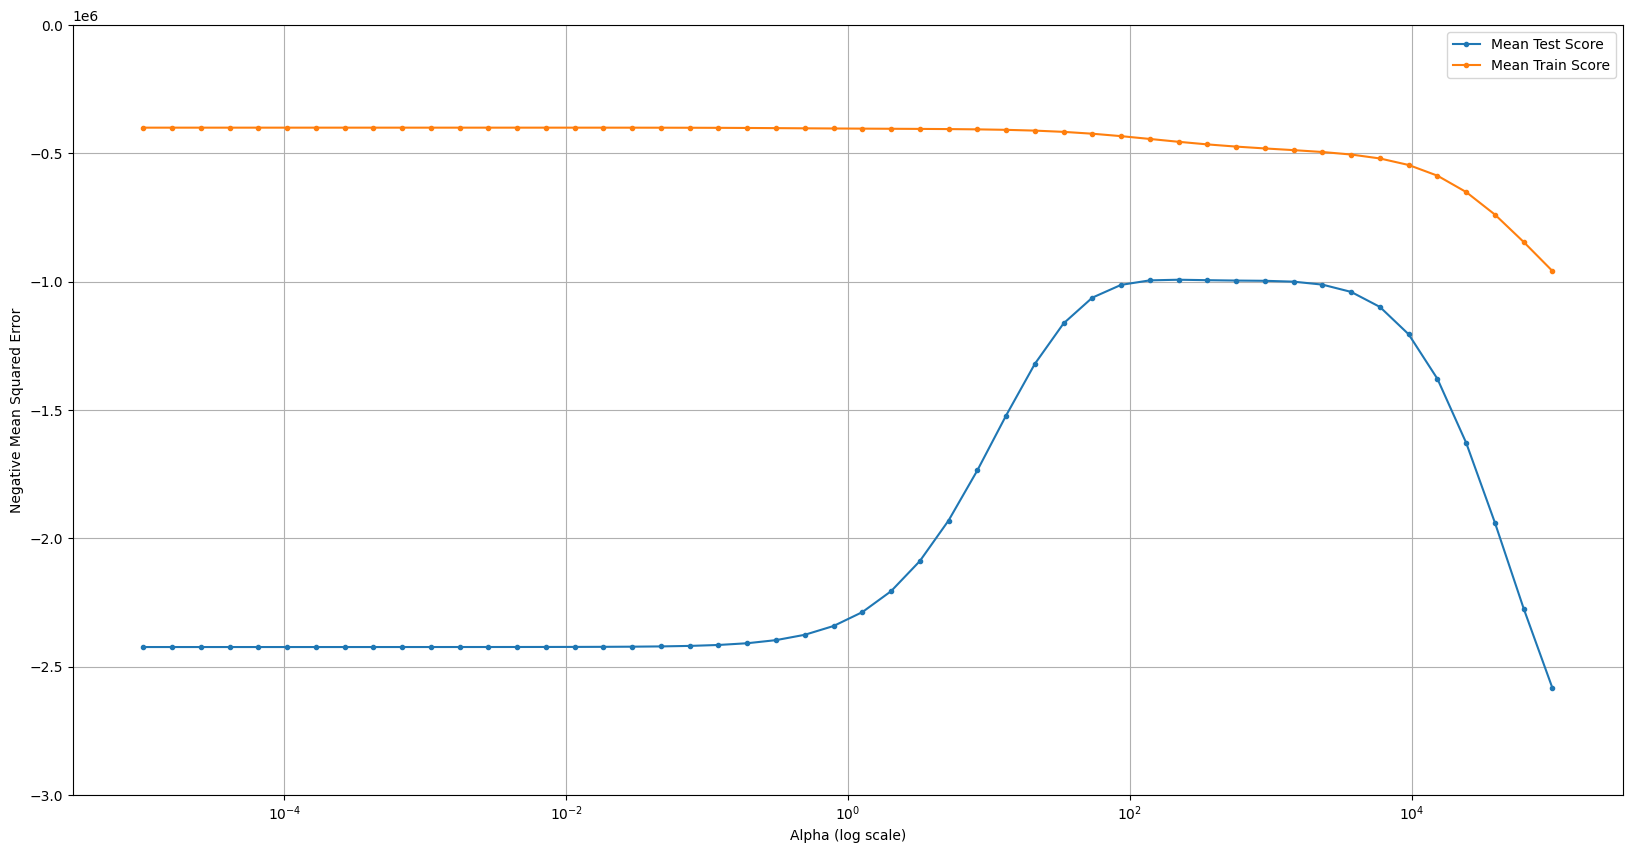

In [96]:
cv_results = pd.DataFrame(search_cv.cv_results_)

fig, ax = plt.subplots(1, figsize=(20,10))
ax.plot(param_grid["alpha"], cv_results["mean_test_score"], marker = ".")
ax.plot(param_grid["alpha"], cv_results["mean_train_score"], marker = ".")
ax.set_ylim(-3e6,0)
ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Negative Mean Squared Error")
ax.legend(["Mean Test Score", "Mean Train Score"], loc="best")
ax.grid()

Linear Model: Ridge, K fold

In [97]:
%%capture
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
model = Ridge()
# alpha wie bei GridSearchCV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {
    "alpha": [],
    "mean_train_score": [],
    "mean_test_score": [],
}

for alpha in alpha_values:
    train_mse = []  # List to store MSE for the training set
    val_mse = []  # List to store MSE for the validation set
    for train_index, val_index in kf.split(X_train_final):
        X_train_fold, X_val_fold = X_train_final.iloc[train_index], X_train_final.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Initialize Ridge regression with the current alpha
        model = Ridge(alpha=alpha)
        model.fit(X_train_fold, y_train_fold)
        
        # Predict and calculate MSE for training fold
        y_pred_train = model.predict(X_train_fold)
        train_mse.append(mean_squared_error(y_train_fold, y_pred_train))
        
        # Predict and calculate MSE for validation fold
        y_pred_val = model.predict(X_val_fold)
        val_mse.append(mean_squared_error(y_val_fold, y_pred_val))
    
    # Average MSE for this alpha
    cv_results["alpha"].append(alpha)
    cv_results["mean_train_score"].append(-np.mean(train_mse))
    cv_results["mean_test_score"].append(-np.mean(val_mse))

cv_results = pd.DataFrame(cv_results)

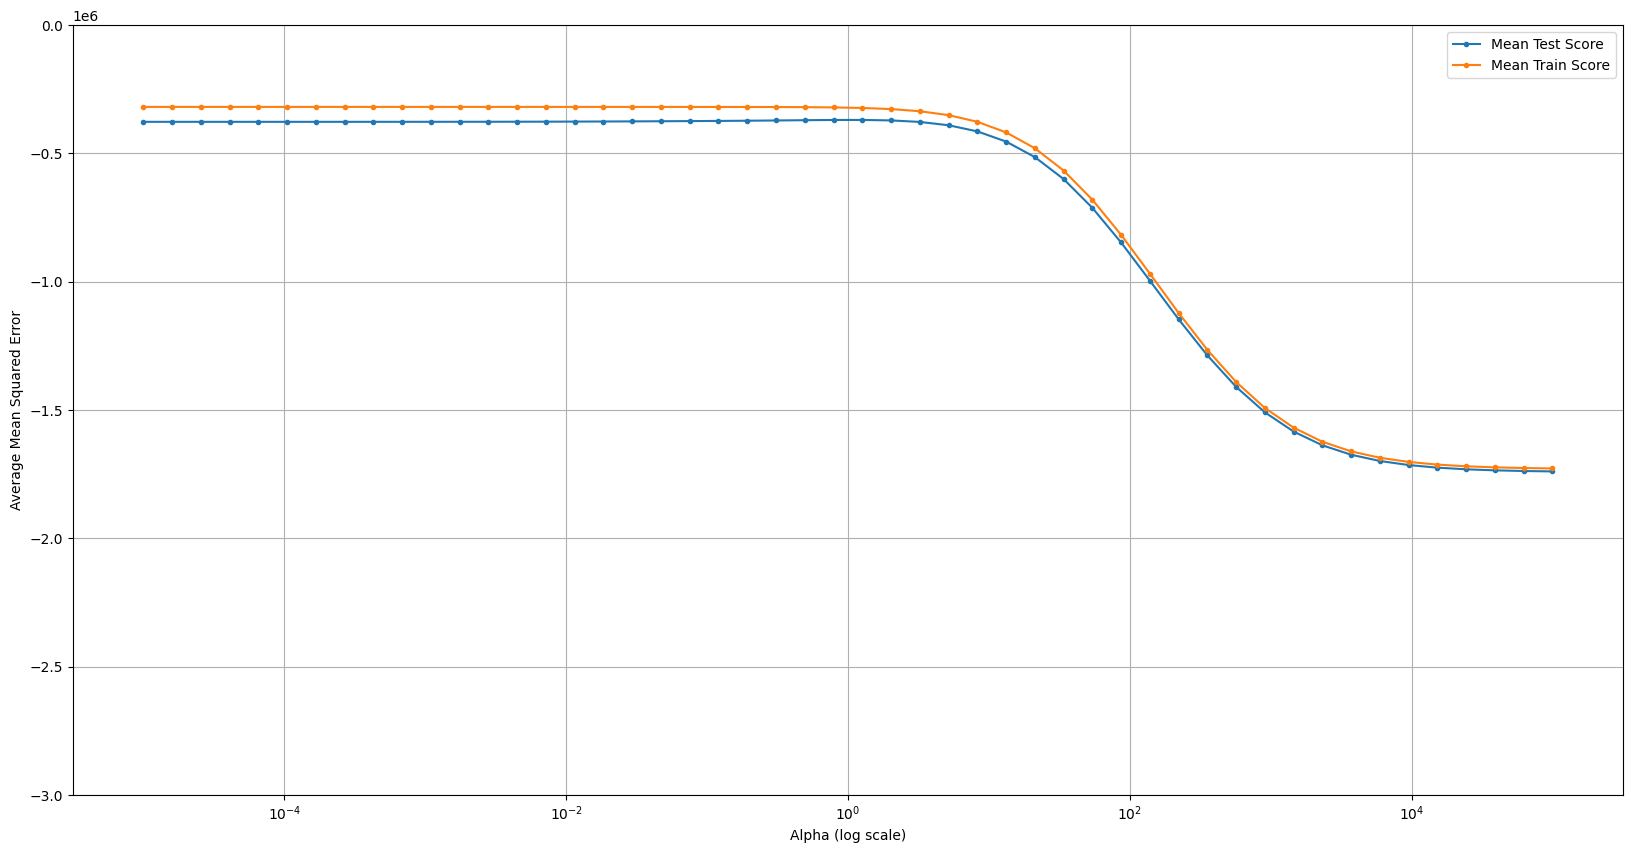

In [98]:

plot_wrapper(cv_results, ylim=(-3e6, 0))

Linear Model: Lasso, Grid Search

In [99]:
%%capture
from sklearn.linear_model import Lasso
model = Lasso()
search_cv = GridSearchCV(model, param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)
search_cv.fit(X_train_final, y_train)
cv_results = pd.DataFrame(search_cv.cv_results_)

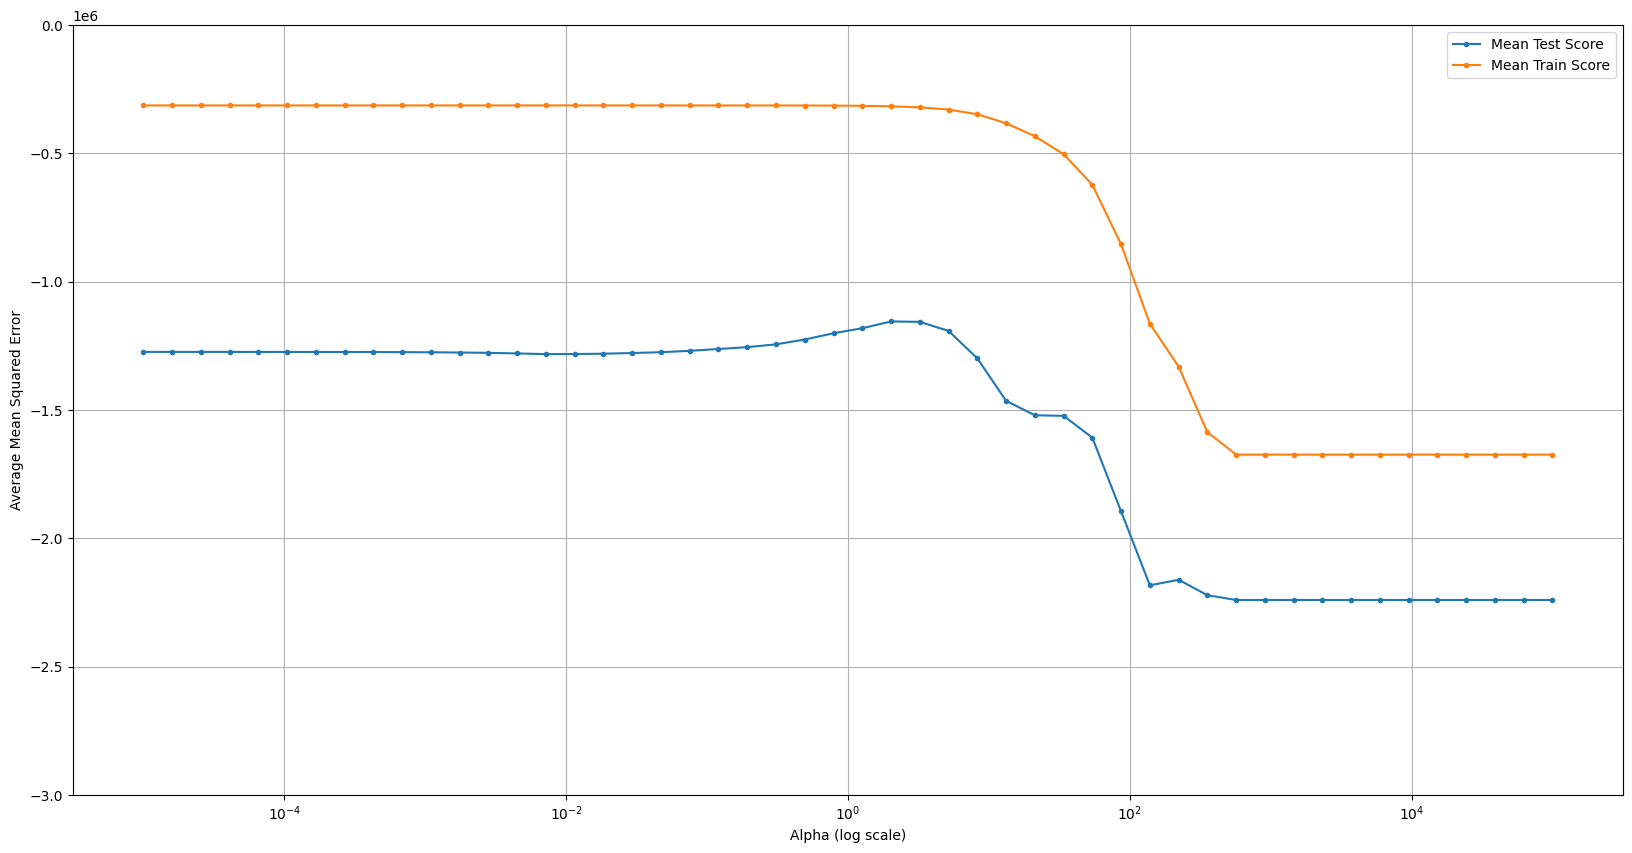

In [100]:
plot_wrapper(cv_results, ylim={-3e6,0})

Linear Model: Lasso, K folf CV

In [101]:
%%capture
model = Lasso()
# alpha wie bei GridSearchCV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {
    "alpha": [],
    "mean_train_score": [],
    "mean_test_score": [],
}

for alpha in alpha_values:
    train_mse = []  # List to store MSE for the training set
    val_mse = []  # List to store MSE for the validation set
    for train_index, val_index in kf.split(X_train_final):
        X_train_fold, X_val_fold = X_train_final.iloc[train_index], X_train_final.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Initialize Ridge regression with the current alpha
        model = Lasso(alpha=alpha)
        model.fit(X_train_fold, y_train_fold)
        
        # Predict and calculate MSE for training fold
        y_pred_train = model.predict(X_train_fold)
        train_mse.append(mean_squared_error(y_train_fold, y_pred_train))
        
        # Predict and calculate MSE for validation fold
        y_pred_val = model.predict(X_val_fold)
        val_mse.append(mean_squared_error(y_val_fold, y_pred_val))
    
    # Average MSE for this alpha
    cv_results["alpha"].append(alpha)
    cv_results["mean_train_score"].append(-np.mean(train_mse))
    cv_results["mean_test_score"].append(-np.mean(val_mse))

cv_results = pd.DataFrame(cv_results)

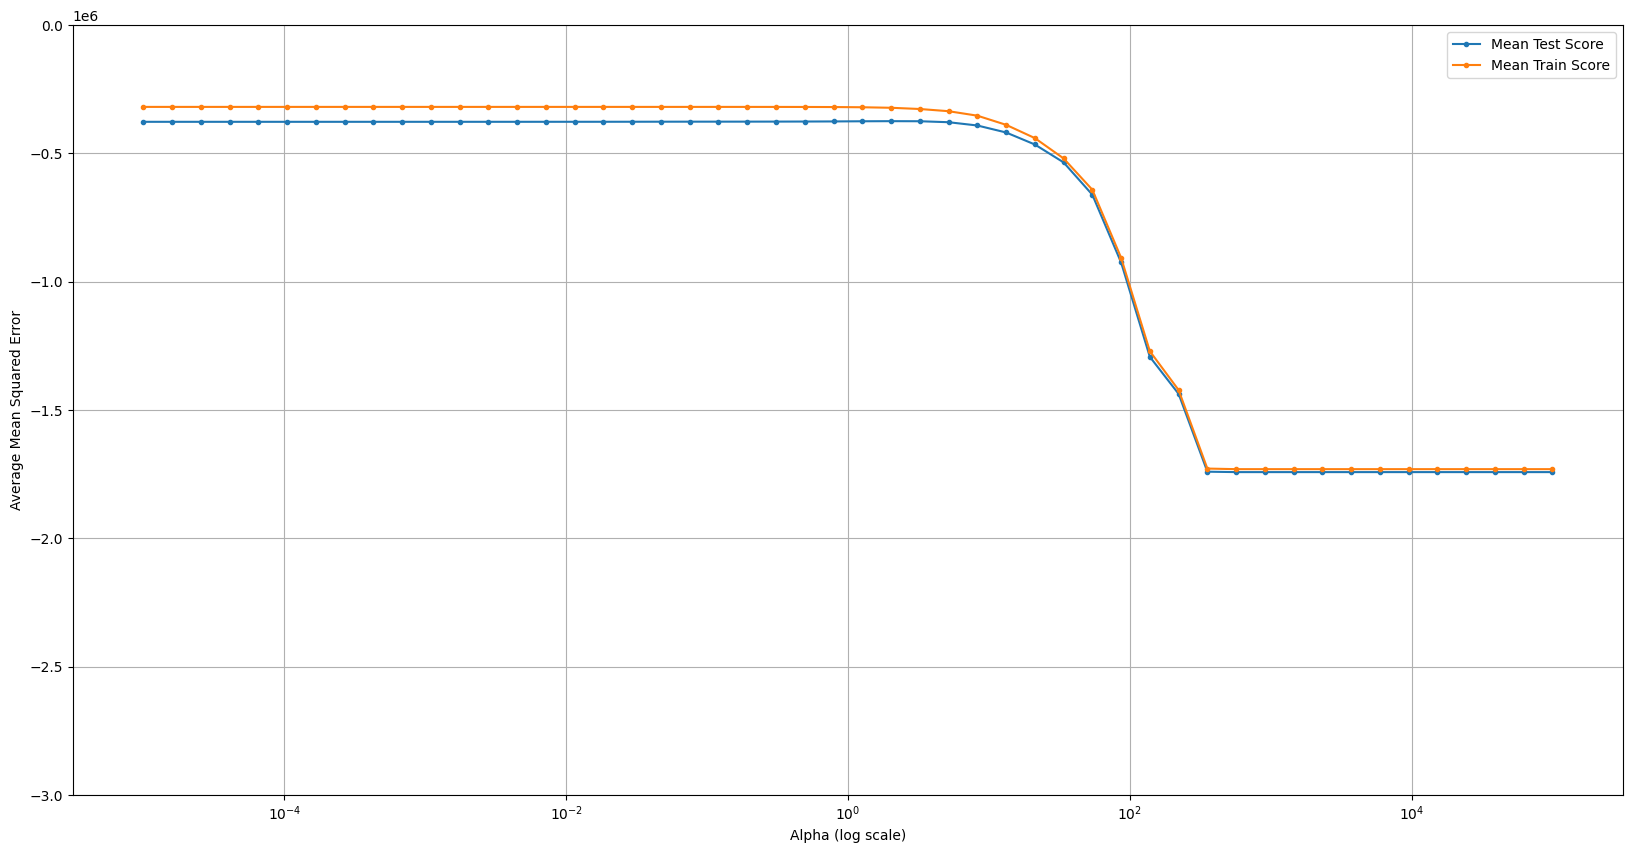

In [102]:
plot_wrapper(cv_results, ylim={-3e6,0})

Kernel Ridge, Grid Search

In [103]:
%%capture
from sklearn.kernel_ridge import KernelRidge
model = KernelRidge(kernel="rbf")

search_cv = GridSearchCV(model, param_grid, cv = 5, verbose= 3, scoring = "neg_mean_squared_error", return_train_score= True)
search_cv.fit(X_train_final, y_train)
cv_results = pd.DataFrame(search_cv.cv_results_)


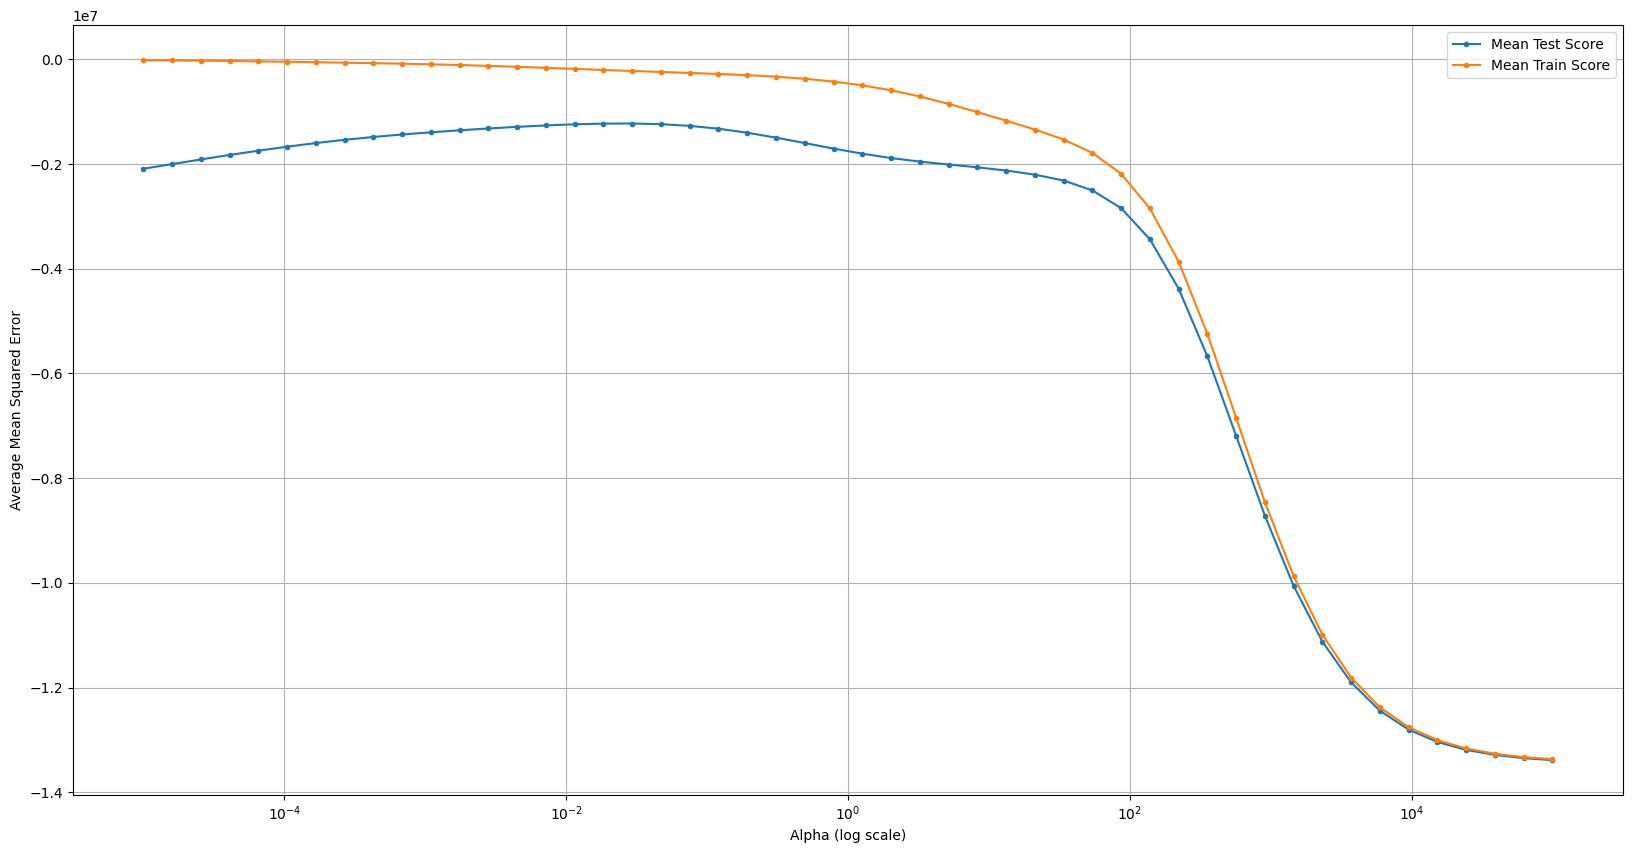

In [104]:
plot_wrapper(cv_results, ylim=None)

In [105]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold


# alpha wie bei GridSearchCV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {
    "alpha": [],
    "mean_train_score": [],
    "mean_test_score": [],
}

for alpha in alpha_values:
    train_mse = []  # List to store MSE for the training set
    val_mse = []  # List to store MSE for the validation set
    for train_index, val_index in kf.split(X_train_final):
        X_train_fold, X_val_fold = X_train_final.iloc[train_index], X_train_final.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Initialize Ridge regression with the current alpha
        model = KernelRidge(alpha=alpha, kernel="rbf", gamma=0.1)
        model.fit(X_train_fold, y_train_fold)
        
        # Predict and calculate MSE for training fold
        y_pred_train = model.predict(X_train_fold)
        train_mse.append(mean_squared_error(y_train_fold, y_pred_train))
        
        # Predict and calculate MSE for validation fold
        y_pred_val = model.predict(X_val_fold)
        val_mse.append(mean_squared_error(y_val_fold, y_pred_val))
    
    # Average MSE for this alpha
    cv_results["alpha"].append(alpha)
    cv_results["mean_train_score"].append(np.mean(train_mse))
    cv_results["mean_test_score"].append(np.mean(val_mse))

cv_results = pd.DataFrame(cv_results)

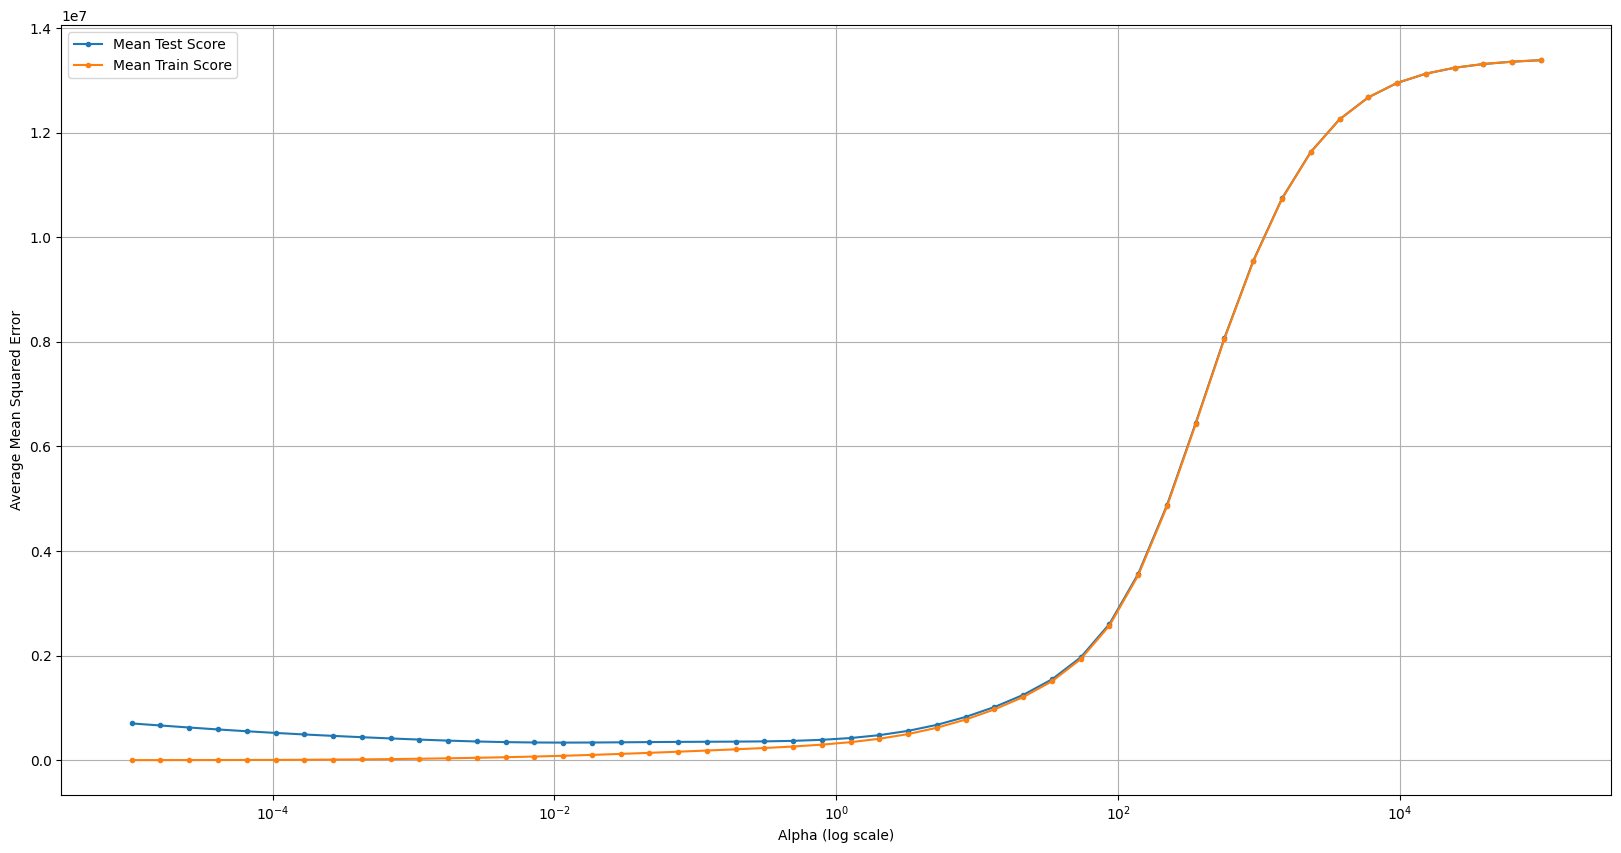

In [106]:
plot_wrapper(cv_results, ylim=None)